In [5]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np


In [6]:
data_dir = Path("data")
image_dir = data_dir / "img"
label_dir = data_dir / "labels"
sample_index = 1

image_paths = sorted(image_dir.glob("*.JPG"))
samples = [
    {
        "image_path": image_path,
        "label_path": label_dir / f"{image_path.stem}.txt",
    }
    for image_path in image_paths
    if (label_dir / f"{image_path.stem}.txt").exists()
]
if not samples:
    raise FileNotFoundError("No JPG/TXT annotation pairs found in data/img and data/labels")

sample = samples[sample_index]
image_bgr = cv2.imread(str(sample["image_path"]), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise FileNotFoundError(sample["image_path"])

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
height, width = image_rgb.shape[:2]
segformer_mask = np.zeros((height, width), dtype=np.uint8)

with sample["label_path"].open("r", encoding="utf-8") as file:
    for line_number, line in enumerate(file, start=1):
        values = line.strip().split()
        if not values:
            continue
        coords = np.asarray(values[1:], dtype=np.float32)
        if coords.size < 6 or coords.size % 2 != 0:
            raise ValueError(f"Bad polygon at {sample['label_path']}:{line_number}")

        points = coords.reshape(-1, 2)
        points[:, 0] *= width - 1
        points[:, 1] *= height - 1
        polygon = np.rint(points).astype(np.int32)
        polygon[:, 0] = np.clip(polygon[:, 0], 0, width - 1)
        polygon[:, 1] = np.clip(polygon[:, 1], 0, height - 1)
        cv2.fillPoly(segformer_mask, [polygon], 1)

print(sample["image_path"].name)
print("image_rgb", image_rgb.shape, image_rgb.dtype)
print("segformer_mask", segformer_mask.shape, segformer_mask.dtype, sorted(np.unique(segformer_mask).tolist()))


66edabdc-DSCN5185.JPG
image_rgb (1704, 2272, 3) uint8
segformer_mask (1704, 2272) uint8 [0, 1]


In [7]:
import importlib
import cv_analysis.post_segformer as post_segformer

post_segformer = importlib.reload(post_segformer)
TalcCVPipeline = post_segformer.TalcCVPipeline
pipeline = TalcCVPipeline.from_yaml("cv_analysis/post_segformer.yaml")


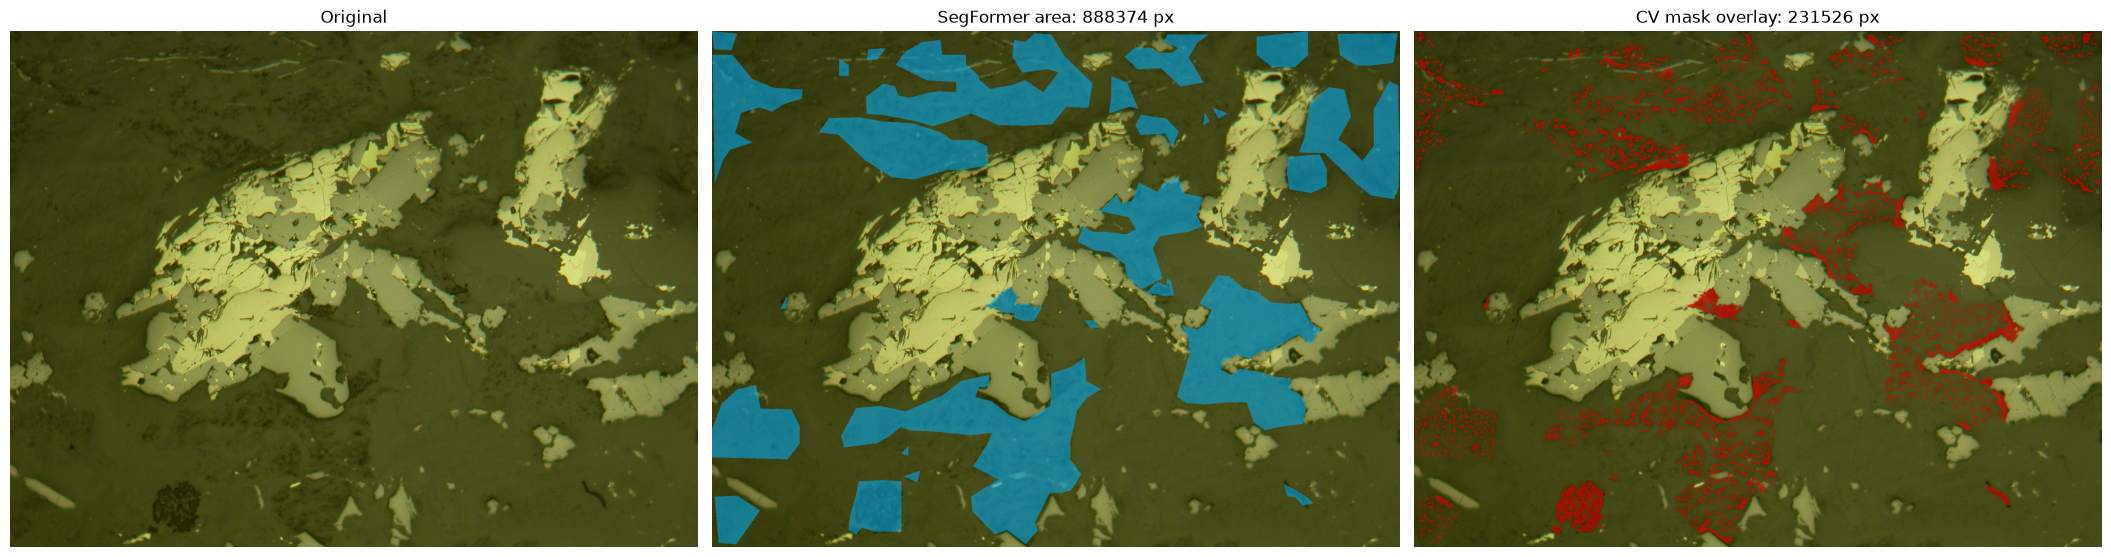

In [8]:
result_mask = pipeline(image_rgb, segformer_mask)

segformer_overlay = image_rgb.copy()
segformer_bool = segformer_mask.astype(bool)
segformer_color = np.array([0, 180, 255], dtype=np.float32)

result_overlay = image_rgb.copy()
result_bool = result_mask.astype(bool)
result_color = np.array([255, 0, 0], dtype=np.float32)
alpha = 0.55

segformer_overlay[segformer_bool] = (
    (1.0 - alpha) * segformer_overlay[segformer_bool].astype(np.float32)
    + alpha * segformer_color
).astype(np.uint8)
result_overlay[result_bool] = (
    (1.0 - alpha) * result_overlay[result_bool].astype(np.float32)
    + alpha * result_color
).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(21, 8), constrained_layout=True)
views = [
    (image_rgb, "Original"),
    (segformer_overlay, f"SegFormer area: {int(segformer_bool.sum())} px"),
    (result_overlay, f"CV mask overlay: {int(result_bool.sum())} px"),
]

for ax, (view, title) in zip(axes, views):
    ax.imshow(view)
    ax.set_title(title)
    ax.axis("off")

plt.show()
